In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
%matplotlib inline
import folium

In [2]:
counties = gpd.read_file(r'C:\Users\user\workspace\c11\Python\projects\geospatial-MHow682\data\county\tncounty.shp')

In [3]:
counties.head()

,OBJECTID,NAME,KEY,SHAPE_AREA,SHAPE_LEN,geometry
0,76,Chester,47023,8.049024e+09,520461.080124,"POLYGON ((1137985.762 344601.643, 1137965.07 3..."
1,77,Wayne,47181,2.050741e+10,666520.678598,"POLYGON ((1365052.057 391716.806, 1365746.554 ..."
2,78,Tipton,47167,1.319125e+10,865093.887634,"MULTIPOLYGON (((886814.33 400456.525, 886774.3..."
3,79,Hamilton,47065,1.604776e+10,652926.001078,"POLYGON ((2274954.438 239788.911, 2274090.61 2..."
4,80,Stewart,47161,1.375003e+10,490090.336180,"POLYGON ((1382472.783 743972.302, 1382445.171 ..."


In [4]:
unemp_vs_od = pd.read_csv(r'C:\Users\user\workspace\c11\Python\projects\prescribers-but-python-mothman-s-medicine\data\unemp_vs_od.csv')

In [5]:
unemp_vs_od.head()

,COUNTY,STATE,PERIOD NAME,YEAR,UNEMPLOYMENT RATE,FIPSCOUNTY,OVERDOSE DEATHS
0,Anderson,TN,December,2018,3.2,47001.0,18.0
1,Bedford,TN,December,2018,3.2,47003.0,7.0
2,Benton,TN,December,2018,3.8,47005.0,1.0
3,Bledsoe,TN,December,2018,5.4,47007.0,3.0
4,Blount,TN,December,2018,2.8,47009.0,30.0


In [6]:
compare = pd.merge(left = counties, right = unemp_vs_od, 
                    left_on = 'NAME', right_on = 'COUNTY')
compare.head()

,OBJECTID,NAME,KEY,SHAPE_AREA,SHAPE_LEN,geometry,COUNTY,STATE,PERIOD NAME,YEAR,UNEMPLOYMENT RATE,FIPSCOUNTY,OVERDOSE DEATHS
0,76,Chester,47023,8.049024e+09,520461.080124,"POLYGON ((1137985.762 344601.643, 1137965.07 3...",Chester,TN,December,2018,3.0,47023.0,1.0
1,77,Wayne,47181,2.050741e+10,666520.678598,"POLYGON ((1365052.057 391716.806, 1365746.554 ...",Wayne,TN,December,2018,2.9,47181.0,4.0
2,78,Tipton,47167,1.319125e+10,865093.887634,"MULTIPOLYGON (((886814.33 400456.525, 886774.3...",Tipton,TN,December,2018,4.4,47167.0,12.0
3,79,Hamilton,47065,1.604776e+10,652926.001078,"POLYGON ((2274954.438 239788.911, 2274090.61 2...",Hamilton,TN,December,2018,2.7,47065.0,41.0
4,80,Stewart,47161,1.375003e+10,490090.336180,"POLYGON ((1382472.783 743972.302, 1382445.171 ...",Stewart,TN,December,2018,2.9,47161.0,6.0


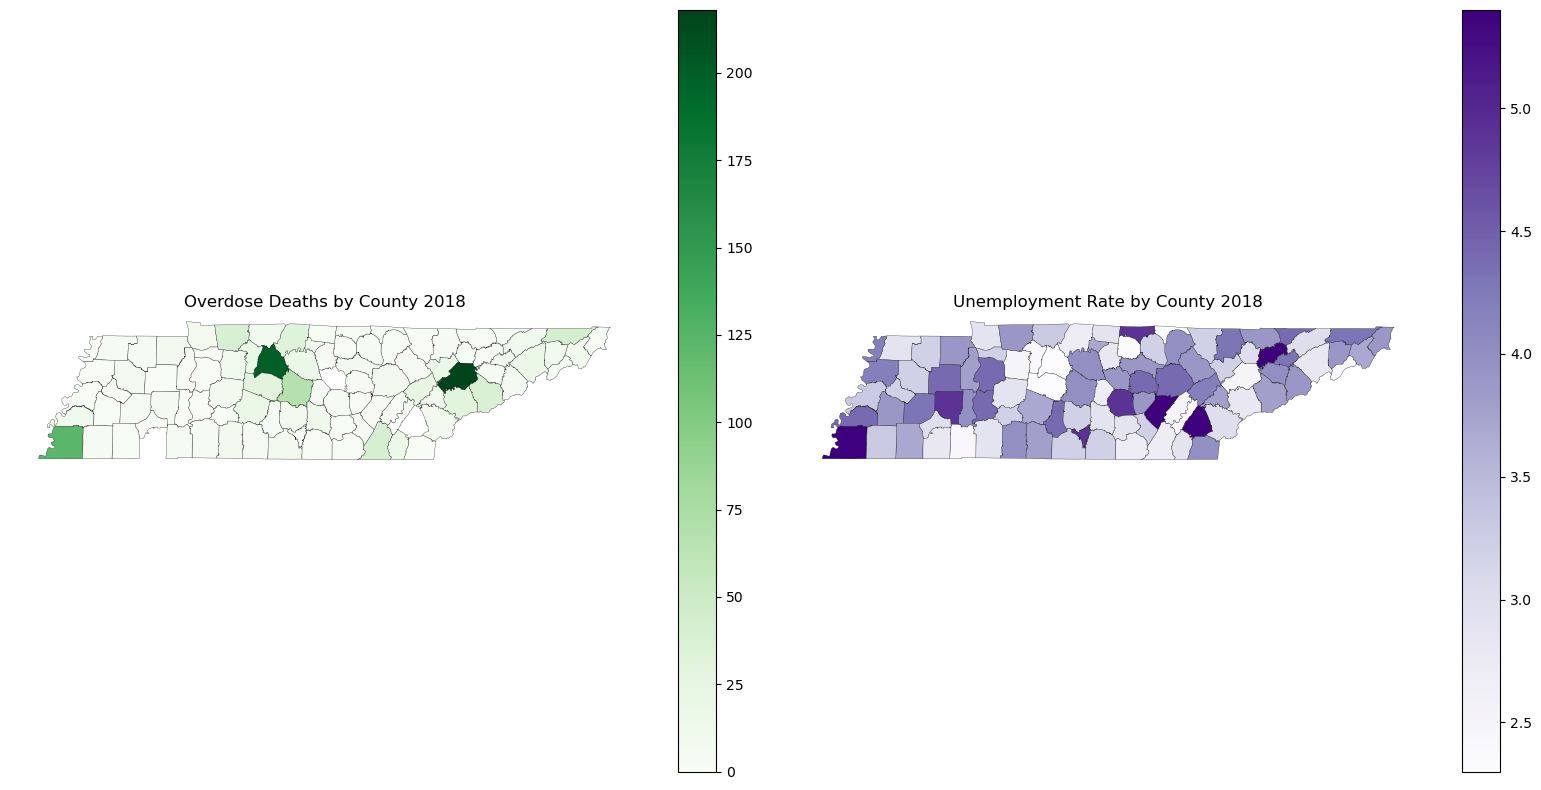

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

compare.plot(
    column="OVERDOSE DEATHS",
    cmap="Greens",
    linewidth=0.2, edgecolor="black",
    legend=True, ax=axes[0],
)
axes[0].set_title("Overdose Deaths by County 2018")
axes[0].axis("off")

compare.plot(
    column="UNEMPLOYMENT RATE",
    cmap="Purples",
    linewidth=0.2, edgecolor="black",
    legend=True, ax=axes[1],
)
axes[1].set_title("Unemployment Rate by County 2018")
axes[1].axis("off")

plt.tight_layout()
plt.show()
fig.savefig("death_vs_unemp.png")

In [8]:
if compare.crs is None or compare.crs.to_epsg() != 4326:
    compare = compare.to_crs(epsg=4326)

name_col = "NAME" 

m = folium.Map(tiles="cartodbpositron", zoom_start=7)

folium.Choropleth(
    geo_data=compare.to_json(),                   
    data=compare[[name_col, "OVERDOSE DEATHS"]],  
    columns=[name_col, "OVERDOSE DEATHS"],
    key_on=f"feature.properties.{name_col}",    
    fill_color="Purples",
    fill_opacity=0.8,
    line_opacity=0.5,
    nan_fill_color="#dddddd",
    legend_name="Overdose Deaths (2018)"
).add_to(m)

folium.GeoJson(
    compare,
    name="Details",
    style_function=lambda x: {"weight": 0.5, "color": "black", "fillOpacity": 0},
    tooltip=folium.features.GeoJsonTooltip(
        fields=[name_col, "OVERDOSE DEATHS", "UNEMPLOYMENT RATE"],
        aliases=["County", "Overdose deaths", "Unemployment rate"],
        localize=True
    ),
).add_to(m)

minx, miny, maxx, maxy = compare.total_bounds
m.fit_bounds([[miny, minx], [maxy, maxx]])

m.save("tn_overdose_choropleth.html")